Text-based DistillBert Classification:
Uses distilbert-base-uncased

Imports

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, DistilBertForSequenceClassification
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Tokenizer+Model

In [ ]:

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModel.from_pretrained(MODEL_NAME)

base_model = base_model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Data Extraction

In [ ]:
import os
import re
import numpy as np

def read_text_files_with_labels(path):
    texts = []
    labels = []

    class_folders = sorted([
    f for f in os.listdir(path)
    if os.path.isdir(os.path.join(path, f)) and not f.startswith(".")
]) #Avoids hidden files being picked up

    label_map = {class_name: idx for idx, class_name in enumerate(class_folders)}

    for class_name in class_folders:
        class_path = os.path.join(path, class_name)

        if os.path.isdir(class_path):
            file_names = sorted(os.listdir(class_path))

            for file_name in file_names:
                file_path = os.path.join(class_path, file_name)

                if os.path.isfile(file_path):
                    # Remove extension
                    file_name_no_ext, _ = os.path.splitext(file_name)

                    # Replace "_" with space
                    text = file_name_no_ext.replace('_', ' ')

                    # Remove digits
                    text_without_digits = re.sub(r'\d+', '', text)

                    texts.append(text_without_digits)
                    labels.append(label_map[class_name])

    return np.array(texts), np.array(labels)


Data Collection

In [ ]:
DATA_ROOT = "/work/TALC/ensf617_2026w/garbage_data"

train_texts, train_labels = read_text_files_with_labels(os.path.join(DATA_ROOT, "CVPR_2024_dataset_Train"))
val_texts, val_labels = read_text_files_with_labels(os.path.join(DATA_ROOT, "CVPR_2024_dataset_Val"))
test_texts, test_labels = read_text_files_with_labels(os.path.join(DATA_ROOT, "CVPR_2024_dataset_Test"))

print("Train samples:", len(train_texts))
print("Val samples:", len(val_texts))
print("Test samples:", len(test_texts))

Train samples: 200
Val samples: 205
Test samples: 161


Text Dataset

In [ ]:
MAX_LEN = 384

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long),
            "text": text 
        }

Data-Loaders

In [ ]:

BATCH_SIZE = 16

train_dataset = TextDataset(train_texts, train_labels, tokenizer)
val_dataset   = TextDataset(val_texts, val_labels, tokenizer)
test_dataset  = TextDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

Classification Head

In [ ]:

class TextClassifier(nn.Module):
    def __init__(self, num_classes, base_model):
        super().__init__()
        self.base_model = base_model
        hidden_size = base_model.config.hidden_size
        self.fc = nn.Linear(hidden_size, num_classes)


    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        # Mean pooling
        last_hidden = outputs.last_hidden_state  # (batch, seq_len, hidden_size)
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_embeddings = torch.sum(last_hidden * mask_expanded, dim=1)
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        pooled = sum_embeddings / sum_mask  # (batch, hidden_size)
        return self.fc(pooled)

Model Instantiation

In [ ]:
model = TextClassifier(num_classes=4, base_model=base_model).to(device)

Optimizer + Loss

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

Training Loop

In [ ]:
EPOCHS = 10

train_losses = []
val_losses = []
misclassified_files = []

for epoch in range(EPOCHS):

    # Training

    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)

    # Validation

    model.eval()
    val_loss_total = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            file_names = batch.get("file_name", [None]*labels.size(0))  # fallback if not present

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss_total / len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)

    # Logging

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc:  {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.4f}")
    print("-" * 40)

Epoch 1/10
Train Loss: 1.3542
Train Acc:  0.3400
Val Loss:   1.3124
Val Acc:    0.4683
----------------------------------------
Epoch 2/10
Train Loss: 1.2451
Train Acc:  0.6150
Val Loss:   1.1929
Val Acc:    0.6634
----------------------------------------
Epoch 3/10
Train Loss: 1.0756
Train Acc:  0.6950
Val Loss:   1.0220
Val Acc:    0.7024
----------------------------------------
Epoch 4/10
Train Loss: 0.8638
Train Acc:  0.7650
Val Loss:   0.8545
Val Acc:    0.7268
----------------------------------------
Epoch 5/10
Train Loss: 0.6666
Train Acc:  0.8350
Val Loss:   0.7156
Val Acc:    0.7610
----------------------------------------
Epoch 6/10
Train Loss: 0.4804
Train Acc:  0.8850
Val Loss:   0.6372
Val Acc:    0.7805
----------------------------------------
Epoch 7/10
Train Loss: 0.3648
Train Acc:  0.9050
Val Loss:   0.5832
Val Acc:    0.7805
----------------------------------------
Epoch 8/10
Train Loss: 0.2690
Train Acc:  0.9400
Val Loss:   0.5689
Val Acc:    0.7902
-----------------

Testing Block

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model.eval()
all_preds = []
misclassified_texts = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["test"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())

        # Capture misclassified samples
        mis_idx = (preds != labels).nonzero(as_tuple=True)[0]
        for idx in mis_idx:
            misclassified_texts.append(batch["text"][idx])  # assuming your dataset returns 'text'

# Compute accuracy
accuracy = (torch.tensor(all_preds) == torch.tensor(test_labels)).float().mean()
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Number of misclassified samples: {len(misclassified_texts)}")


KeyError: 'test'

Loss Chart

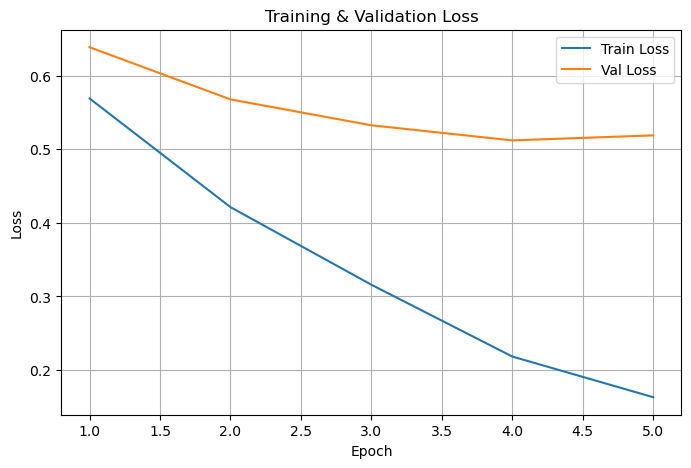

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("/home/le.song/Assignment2/ls_chart_part2")

Saving Model

In [ ]:
torch.save(model.state_dict(), "/home/le.song/Assignment2/clean_text_classifier.pth")

Extract Embeddings

In [ ]:
def extract_text_embeddings_batchwise(text_list, model, tokenizer, batch_size=16, max_len=MAX_LEN):
    """
    Extract text embeddings efficiently in batches.
    """
    model.eval()
    all_embeddings = []

    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]
        encoding = tokenizer(
            batch_texts,
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = model.base_model(**encoding)
            last_hidden = outputs.last_hidden_state  # (batch, seq_len, hidden_size)
            mask_expanded = encoding['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
            pooled = (last_hidden * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1e-9)
            all_embeddings.append(pooled.cpu())

    return torch.cat(all_embeddings, dim=0).numpy()